# [ Computer Vision ] [ CSE445 ] [ Assignment-2 ]

**Dataset Name:** IoTKITs<br>
**Source Link:** https://data.mendeley.com/datasets/x5thzmkxhy/1

## Configuration

In [1]:
!pip install ultralytics timm --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 4.6 MB/s eta 0:00:00


In [2]:
import os
import json
import random
import copy
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt

# partition splits
splits_dataset_dir = "/kaggle/input/notebooks/Mrpaul0007/self-supervised-learning-nb-0-partition"
ssl_pool_dir    =   os.path.join(splits_dataset_dir,"ssl_pool_images")
val_img_dir     = os.path.join(splits_dataset_dir, "yolo_rho20", "images", "val")
test_img_dir    = os.path.join(splits_dataset_dir, "yolo_rho20", "images", "test")
print("Partition dataset contents:",sorted(os.listdir(splits_dataset_dir)),"\n")

working_dir = "/kaggle/working/"
os.makedirs(working_dir, exist_ok=True)

METHOD = "SimCLR"
FAMILY     = "Contrastive"
ENCODER    = "YOLOv12s backbone"
BEST_YAML  = "yolo12s.yaml"

AUG_CFG = {
    "random_resized_crop_scale":(0.2,1.0),
    "hflip_p":0.5,
    "color_jitter":	(0.4,0.4,0.4,0.1),
    "color_jitter_p": 0.8,
    "grayscale_p": 0.2,
    "gaussian_blur_kernel":	23,
    "gaussian_blur_sigma":(0.1,2.0),
}

SEED       = 42
IMGSZ_SSL  = 224
BATCH      = 16
EPOCHS     = 200
TAU        = 0.2
PROJ_DIM   = 128
LR         = 3e-4

torch.manual_seed(SEED)
random.seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("\n====== Configuration ======\n")
print("Method           :", METHOD)
print("Encoder          :", ENCODER)
print("Detector YAML    :", BEST_YAML)
print("SSL pool dir     :", ssl_pool_dir)
print("Device           :", device)
print("Seed             :", SEED)
print("Image size       :", IMGSZ_SSL)
print("Batch size       :", BATCH)
print("Epochs           :", EPOCHS)
print("LR               :", LR)
print("Tau (NT-Xent)    :", TAU)
print("Projection dim   :", PROJ_DIM)
print("Mixed precision  : ON (AMP)")
print("\nAugmentation policy:")
for k, v in AUG_CFG.items():
    print(f"{k:28s}: {v}")

Partition dataset contents: ['__notebook__.ipynb', '__output__.json', '__results__.html', 'custom.css', 'splits', 'ssl_pool_images', 'yolo_rho20'] 


====== Configuration ======

Method           : SimCLR
Encoder          : YOLOv12s backbone
Detector YAML    : yolo12s.yaml
SSL pool dir     : /kaggle/input/notebooks/Mrpaul0007/self-supervised-learning-nb-0-partition/ssl_pool_images
Device           : cuda
Seed             : 42
Image size       : 224
Batch size       : 16
Epochs           : 200
LR               : 0.0003
Tau (NT-Xent)    : 0.2
Projection dim   : 128
Mixed precision  : ON (AMP)

Augmentation policy:
random_resized_crop_scale   : (0.2, 1.0)
hflip_p                     : 0.5
color_jitter                : (0.4, 0.4, 0.4, 0.1)
color_jitter_p              : 0.8
grayscale_p                 : 0.2
gaussian_blur_kernel        : 23
gaussian_blur_sigma         : (0.1, 2.0)


In [3]:
IMG_EXT = (".jpg", ".jpeg", ".png", ".bmp")

def stem_set(folder):
    names = set()
    for f in os.listdir(folder):
        if not f.lower().endswith(IMG_EXT):
            continue
        stem = f.split("__", 1)[1] if "__" in f else f
        names.add(os.path.splitext(stem)[0])
    return names

ssl_names  = stem_set(ssl_pool_dir)
val_names  = stem_set(val_img_dir)
test_names = stem_set(test_img_dir)
total = len(ssl_names) + len(val_names) + len(test_names)

print("Partition sizes (seed =", SEED,"):")
print(f"SSL pool     : {len(ssl_names):5d}  ({len(ssl_names)/total:6.2%})")
print(f"Validation   : {len(val_names):5d}  ({len(val_names)/total:6.2%})")
print(f"Test holdout : {len(test_names):5d}  ({len(test_names)/total:6.2%})")
print(f"TOTAL |D|    : {total:5d}")

print("\nDisjointness Check:")
i_ts = test_names & ssl_names
i_vs = val_names  & ssl_names
print(f"test ∩ ssl_pool : {len(i_ts)}  -> {'PASS' if not i_ts else 'FAIL'}")
print(f"val  ∩ ssl_pool : {len(i_vs)}  -> {'PASS' if not i_vs else 'FAIL'}")
assert not i_ts and not i_vs, "LEAKAGE"

Partition sizes (seed = 42 ):
SSL pool     :  2485  (79.98%)
Validation   :   311  (10.01%)
Test holdout :   311  (10.01%)
TOTAL |D|    :  3107

Disjointness Check:
test ∩ ssl_pool : 0  -> PASS
val  ∩ ssl_pool : 0  -> PASS


## Extract YOLO Backbone As Encoder

In [4]:
from ultralytics import YOLO
import timm

full = YOLO(BEST_YAML).model
n_bb = len(full.yaml["backbone"])
print("backbone layers:", n_bb)

try:
    backbone = nn.Sequential(*list(full.model[:n_bb]))

    dummy = torch.randn(1, 3, IMGSZ_SSL, IMGSZ_SSL)
    with torch.no_grad():
        out = backbone(dummy)
    print("nn.Sequential backbone worked. Output shape:", out.shape)
    USE_TIMM = False

except Exception as e:
    print("nn.Sequential backbone FAILED (Concat/routing bhenge geche):")
    print(" ", e)
    print("Falling back to timm encoder (ResNet18)")
    USE_TIMM = True
    
    timm_model = timm.create_model("resnet18", pretrained=False, num_classes=0, global_pool="")
    backbone = timm_model

    dummy = torch.randn(1, 3, IMGSZ_SSL, IMGSZ_SSL)
    with torch.no_grad():
        out = backbone(dummy)
    print("timm fallback backbone (ResNet18) ready. Output shape:", out.shape)
    print("NOTE: fallback encoder is architecturally different from the YOLO backbone —")
    print("      weight surgery into the detector in notebook 1b will need a compatible adapter/mapping,")
    print("      this must be documented in the report if this path is triggered.")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
backbone layers: 9
nn.Sequential backbone worked. Output shape: torch.Size([1, 512, 7, 7])


## SimCLR Model + NT-Xent Loss

In [5]:
ENC_DIM = out.shape[1]
print("Encoder output channels:", ENC_DIM)

class SimCLR(nn.Module):
    def __init__(self, enc, dim=ENC_DIM, out_dim=PROJ_DIM):
        super().__init__()
        self.enc  = enc
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.proj = nn.Sequential(
            nn.Linear(dim, 512), nn.ReLU(), nn.Linear(512, out_dim)
        )

    def forward(self, x):
        h = self.pool(self.enc(x)).flatten(1)
        z = F.normalize(self.proj(h), dim=1)
        return h, z

def nt_xent(z1, z2, tau=TAU):
    z = torch.cat([z1, z2])
    N = z1.size(0)
    sim = (z @ z.T) / tau
    mask_value = torch.finfo(sim.dtype).min
    sim.fill_diagonal_(mask_value)
    tgt = torch.cat([torch.arange(N, 2*N), torch.arange(0, N)]).to(z.device)
    return F.cross_entropy(sim, tgt)

model = SimCLR(backbone).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

print("SimCLR model ready. Params:", sum(p.numel() for p in model.parameters()))

Encoder output channels: 512
SimCLR model ready. Params: 5774912


## Augmentation (2 Views) + Dataset

In [6]:
import torchvision.transforms as T

simclr_aug = T.Compose([
    T.RandomResizedCrop(IMGSZ_SSL, scale=AUG_CFG["random_resized_crop_scale"]),
    T.RandomHorizontalFlip(p=AUG_CFG["hflip_p"]),
    T.RandomApply([T.ColorJitter(*AUG_CFG["color_jitter"])], p=AUG_CFG["color_jitter_p"]),
    T.RandomGrayscale(p=AUG_CFG["grayscale_p"]),
    T.GaussianBlur(kernel_size=AUG_CFG["gaussian_blur_kernel"],
                   sigma=AUG_CFG["gaussian_blur_sigma"]),
    T.ToTensor(),
])

class SSLDataset(Dataset):
    def __init__(self, root, transform):
        self.paths = [os.path.join(root, f) for f in os.listdir(root)
                      if f.lower().endswith((".jpg", ".jpeg", ".png"))]
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        v1 = self.transform(img)
        v2 = self.transform(img)
        return v1, v2

dataset = SSLDataset(ssl_pool_dir, simclr_aug)
loader = DataLoader(dataset, batch_size=BATCH, shuffle=True, num_workers=2, drop_last=True)

print("SSL pool images:", len(dataset))
print("Batches per epoch:", len(loader))

SSL pool images: 2485
Batches per epoch: 155


## Sanity Check — Two Augmented Views Of One Image

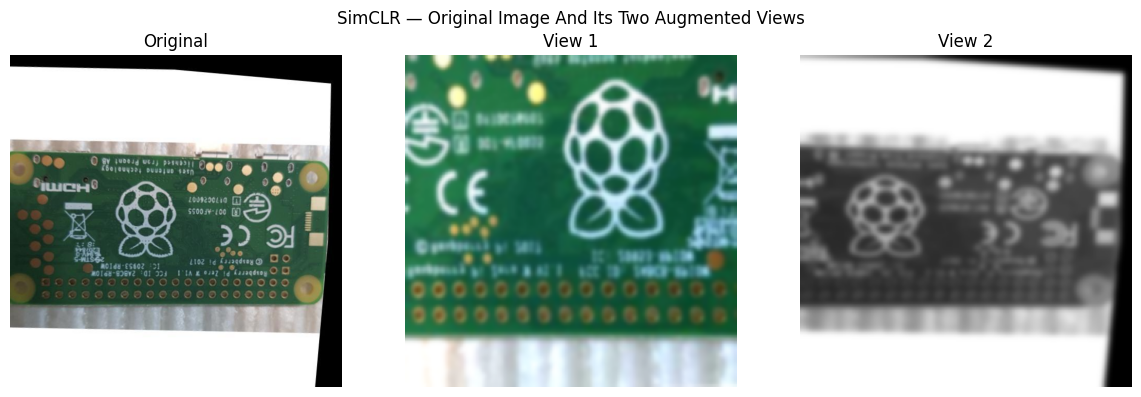

In [7]:
sample_path = dataset.paths[0]
sample_original = Image.open(sample_path).convert("RGB")
sample_v1, sample_v2 = dataset[0]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(sample_original)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(sample_v1.permute(1, 2, 0))
axes[1].set_title("View 1")
axes[1].axis("off")

axes[2].imshow(sample_v2.permute(1, 2, 0))
axes[2].set_title("View 2")
axes[2].axis("off")

plt.suptitle("SimCLR — Original Image And Its Two Augmented Views")
plt.tight_layout()
plt.savefig(os.path.join(working_dir, "simclr_two_views.png"), dpi=150)
plt.show()

## Train SimCLR (200 Epochs, AMP)

In [8]:
scaler = torch.amp.GradScaler("cuda")
loss_history = []

model.train()
for epoch in range(EPOCHS):
    epoch_loss = 0.0
    for v1, v2 in loader:
        v1, v2 = v1.to(device), v2.to(device)

        optimizer.zero_grad()
        with torch.amp.autocast("cuda"):
            _, z1 = model(v1)
            _, z2 = model(v2)
            loss = nt_xent(z1, z2)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(loader)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1:2d}/{EPOCHS}  loss: {avg_loss:.4f}")

Epoch  1/200  loss: 3.0794
Epoch  2/200  loss: 2.8644
Epoch  3/200  loss: 2.5731
Epoch  4/200  loss: 2.2192
Epoch  5/200  loss: 2.1378
Epoch  6/200  loss: 2.0030
Epoch  7/200  loss: 1.9127
Epoch  8/200  loss: 1.7920
Epoch  9/200  loss: 1.7338
Epoch 10/200  loss: 1.5838
Epoch 11/200  loss: 1.5339
Epoch 12/200  loss: 1.4363
Epoch 13/200  loss: 1.3260
Epoch 14/200  loss: 1.3124
Epoch 15/200  loss: 1.2617
Epoch 16/200  loss: 1.2405
Epoch 17/200  loss: 1.1821
Epoch 18/200  loss: 1.1824
Epoch 19/200  loss: 1.1253
Epoch 20/200  loss: 1.0750
Epoch 21/200  loss: 1.0611
Epoch 22/200  loss: 1.0014
Epoch 23/200  loss: 1.0439
Epoch 24/200  loss: 1.0048
Epoch 25/200  loss: 0.9868
Epoch 26/200  loss: 1.0008
Epoch 27/200  loss: 0.9363
Epoch 28/200  loss: 0.9486
Epoch 29/200  loss: 0.9203
Epoch 30/200  loss: 0.9181
Epoch 31/200  loss: 0.8994
Epoch 32/200  loss: 0.8934
Epoch 33/200  loss: 0.8731
Epoch 34/200  loss: 0.8743
Epoch 35/200  loss: 0.8525
Epoch 36/200  loss: 0.8440
Epoch 37/200  loss: 0.8413
E

## Loss Curve

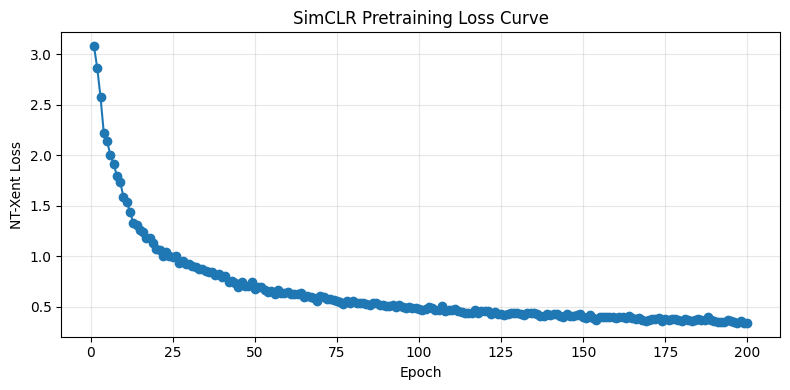

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS + 1), loss_history, marker="o")
plt.xlabel("Epoch")
plt.ylabel("NT-Xent Loss")
plt.title("SimCLR Pretraining Loss Curve")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(working_dir, "simclr_loss_curve.png"), dpi=150)
plt.show()

## Embedding Visualization: t-SNE + Top-5 Nearest Neighbor Retrieval

Validation embeddings shape: (311, 512)


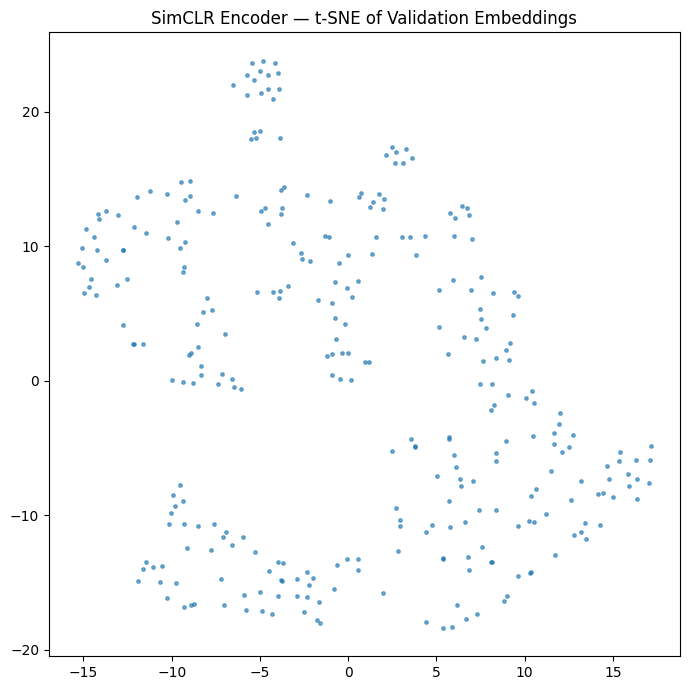

In [10]:
from sklearn.manifold import TSNE
import numpy as np

# eval mode, without augmentation - just resize+tensor
eval_transform = T.Compose([
    T.Resize((IMGSZ_SSL, IMGSZ_SSL)),
    T.ToTensor(),
])

eval_dataset = SSLDataset(val_img_dir, eval_transform)
model.eval()

all_embeddings = []
all_paths = []

with torch.no_grad():
    for i in range(len(eval_dataset)):
        img = Image.open(eval_dataset.paths[i]).convert("RGB")
        x = eval_transform(img).unsqueeze(0).to(device)
        h, _ = model(x)
        all_embeddings.append(h.cpu().numpy()[0])
        all_paths.append(eval_dataset.paths[i])

all_embeddings = np.array(all_embeddings)
print("Validation embeddings shape:", all_embeddings.shape)

# t-SNE plot
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30)
emb_2d = tsne.fit_transform(all_embeddings)

plt.figure(figsize=(7, 7))
plt.scatter(emb_2d[:, 0], emb_2d[:, 1], s=6, alpha=0.6)
plt.title("SimCLR Encoder — t-SNE of Validation Embeddings")
plt.tight_layout()
plt.savefig(os.path.join(working_dir, "simclr_tsne.png"), dpi=150)
plt.show()

## Top-5 nearest-neighbor

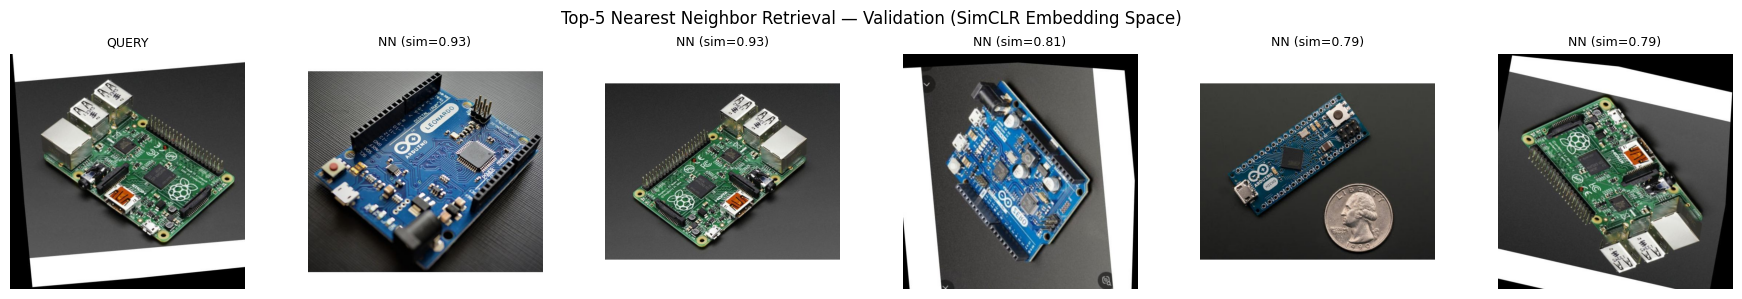

In [11]:
from sklearn.metrics.pairwise import cosine_similarity

query_idx = 0
sims = cosine_similarity([all_embeddings[query_idx]], all_embeddings)[0]
top6 = np.argsort(-sims)[:6]

fig, axes = plt.subplots(1, 6, figsize=(18, 3))
for ax, idx in zip(axes, top6):
    img = Image.open(all_paths[idx]).convert("RGB")
    ax.imshow(img)
    tag = "QUERY" if idx == query_idx else f"NN (sim={sims[idx]:.2f})"
    ax.set_title(tag, fontsize=9)
    ax.axis("off")

plt.suptitle("Top-5 Nearest Neighbor Retrieval — Validation (SimCLR Embedding Space)")
plt.tight_layout()
plt.savefig(os.path.join(working_dir, "simclr_retrieval_panel.png"), dpi=150)
plt.show()

## Save Best Checkpoint

In [12]:
ckpt_path = os.path.join(working_dir, "simclr_backbone.pt")
torch.save(model.enc.state_dict(), ckpt_path)
print("SimCLR backbone saved:", ckpt_path)

SimCLR backbone saved: /kaggle/working/simclr_backbone.pt
